# AICE Associate 특강 모의고사

## 스터디카페 이용 데이터 - 전처리 및 머신러닝 모델링

2회차에서 다룬 스터디카페 이용 데이터의 원본(raw) 버전을 활용합니다. 이번 데이터에는 실제 결측치와 이상치가 포함되어 있습니다.\
데이터를 전처리(이상치 처리, 결측치 처리, 인코딩, 스케일링)한 후, 머신러닝 모델로 고객의 멤버십(membership) 가입 여부를 예측하고 성능을 평가하세요.

---
reservation_id: 예약 고유번호 <br>
branch: 지점명 (강남점, 홍대점, 신촌점, 건대점, 잠실점) <br>
seat_type: 좌석 타입 (오픈석, 개인석, 스터디룸) <br>
age_group: 연령대 (10대, 20대, 30대, 40대이상) <br>
day_type: 요일 구분 (평일, 주말) <br>
usage_minutes: 이용 시간(분) <br>
rate_per_hour: 시간당 요금(원) <br>
visit_count: 당월 누적 방문 횟수 <br>
membership: 멤버십 가입 여부 (Y/N) (타겟 변수) <br>
satisfaction: 이용 만족도 (1~5점) <br>
currency: 결제 통화 <br>

---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1. 라이브러리를 임포트하는 코드를 작성하고 실행하세요.
---
- Pandas 라이브러리를 별칭 pd로 임포트하세요.
- Seaborn 라이브러리를 별칭 sns로 임포트하세요.
    - 설치되어 있지 않으면 설치해서 임포트하세요.
---

In [ ]:
# 여기에 답안코드를 작성하세요.

import pandas as pd
import seaborn as sns


다음 문항을 풀기 전에 아래의 코드를 실행하세요.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
plt.rc("font", family="NanumGothicCoding")

### 2. 분석할 데이터 파일을 읽어오려고 합니다.
---
pandas 함수로 데이터 파일을 읽고 데이터프레임 변수명 df에 할당하는 코드를 작성하세요.
- study_cafe_usage_raw.csv 파일을 읽어 df에 할당하세요.
- 데이터프레임의 정보와 결측치 현황을 확인하는 코드를 작성하세요.
- 출력된 결과와 일치하지 않는 내용을 아래에서 골라 "답안02" 변수에 저장하세요. (예: 답안02=1)
    1. 데이터의 총 행(row)의 개수는 1,500개이다.
    2. 결측치가 있는 컬럼은 2개이다.
    3. usage_minutes(이용시간)의 최댓값은 500분을 넘지 않는다.
    4. 멤버십 가입(membership='Y') 고객 수가 미가입 고객 수보다 많다.
---

In [ ]:
# 여기에 답안코드를 작성하세요.

df = pd.read_csv('study_cafe_usage_raw.csv')

# print(df.info())
# print(df.isna().sum())
# print(df.describe())
print(df['membership'].value_counts())

답안02 = 3


membership
Y    753
N    747
Name: count, dtype: int64


### 3. usage_minutes 컬럼은 극단적인 이상치를 포함합니다.
---
다음 가이드를 따라 코드를 작성하세요.
- 대상 데이터프레임: df
- Seaborn의 boxplot을 활용하여 usage_minutes의 분포를 먼저 확인하세요.
- usage_minutes 값이 600(분)을 초과하는 데이터를 이상치로 간주하여 제거하세요.
- 전처리 반영된 결과를 새로운 데이터프레임 변수명 df_outlier에 저장하세요.
- 제거된 행(row)의 개수를 "답안03" 변수에 저장하세요. (예: 답안03=10)
---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

(22, 11)


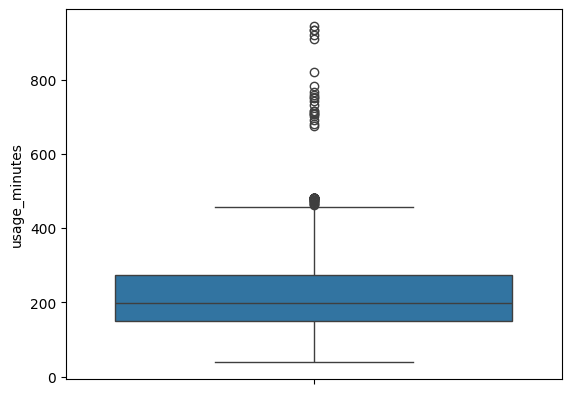

In [ ]:
# 여기에 답안코드를 작성하세요.

sns.boxplot(data=df, y='usage_minutes')

print(df[df['usage_minutes'] > 600].shape)  # (22,11) 600 초과하는 데이터: 22개
df_outlier = df[df['usage_minutes'] <= 600]

답안03 = 22

### 4. 모델링 성능을 제대로 얻기 위해서 결측치 처리는 필수입니다.
---
아래 가이드를 따라 결측치를 처리하세요.
- 대상 데이터프레임: df_outlier
- 컬럼별 결측치 개수를 확인하는 코드를 작성하세요.
- age_group 컬럼의 결측치는 최빈값으로 대체하세요.
- satisfaction 컬럼의 결측치는 있는 행(row)을 삭제하세요.
- 전처리 반영된 결과를 새로운 데이터프레임 변수명 df_na에 저장하세요.
- 처리 전 총 결측치 개수를 "답안04" 변수에 저장하세요. (예: 답안04=10)
---

In [ ]:
# 여기에 답안코드를 작성하세요.

print(df.isna().sum())
print(df.isna().sum().sum())

답안04 = 105

df_na = df_outlier.copy()
df_na['age_group'] = df_na['age_group'].fillna(df['age_group'].mode()[0]) # mode()[0] -> 최빈값 구하기. 꼭 0번째 가져와야 함!

df_na = df_na.dropna(subset=['satisfaction'])
df_na.isna().sum()

reservation_id     0
branch             0
seat_type          0
age_group         45
day_type           0
usage_minutes      0
rate_per_hour      0
visit_count        0
membership         0
satisfaction      60
currency           0
dtype: int64
105


,0
reservation_id,0
branch,0
seat_type,0
age_group,0
day_type,0
usage_minutes,0
rate_per_hour,0
visit_count,0
membership,0
satisfaction,0


### 5. 분석에 불필요한 컬럼을 삭제하세요.
---
다음 가이드를 따라 코드를 작성하세요.
- 대상 데이터프레임: df_na
- 제거할 컬럼: reservation_id, currency
    - reservation_id는 예약 건마다 고유한 값으로 분석에 의미가 없습니다.
    - currency는 모든 행의 값이 "KRW"로 동일하여 분석에 의미가 없습니다.
- 전처리 반영된 결과를 새로운 데이터프레임 변수명 df_del에 저장하세요.
---

In [ ]:
# 여기에 답안코드를 작성하세요.

df_del = df_na.drop(['reservation_id', 'currency'], axis=1) # axis=1 : 컬럼
df_del.shape


(1418, 9)

### 6. 타겟 변수를 수치형으로 변환하세요.
---
다음 가이드를 따라 코드를 작성하세요.
- 대상 데이터프레임: df_del
- membership 컬럼의 값을 Y는 1, N은 0으로 변환하세요.
    - map() 또는 replace()를 활용하세요.
- 전처리 반영된 결과를 새로운 데이터프레임 변수명 df_enc에 저장하세요.
---

In [ ]:
# 여기에 답안코드를 작성하세요.

df_enc = df_del.copy()
df_enc['membership'] = df_enc['membership'].map({'Y':1, 'N':0})
df_enc['membership'].value_counts()


,count
membership,
1,710
0,708


### 7. 원-핫 인코딩(One-hot encoding)은 범주형 변수를 1과 0의 이진형 벡터로 변환하기 위하여 사용하는 방법입니다.
---
원-핫 인코딩으로 아래 조건에 해당하는 컬럼 데이터를 변환하세요.
- 대상 데이터프레임: df_enc
- 원-핫 인코딩 대상: object(문자형) 타입의 전체 컬럼 (branch, seat_type, age_group, day_type)
- 활용 함수: Pandas의 get_dummies
- 해당 전처리가 반영된 결과를 데이터프레임 변수 df_preset에 저장해 주세요.
- 전처리가 완료된 후 df_preset의 컬럼 수를 "답안07" 변수에 저장하세요. (예: 답안07=10)
---

In [ ]:
# 여기에 답안코드를 작성하세요.

df_preset = pd.get_dummies(df_enc)

print(df_preset.shape)

답안07 = 19

(1418, 19)


### 8. 훈련 데이터와 평가 데이터를 분리하세요.
---
membership 컬럼을 y로, 나머지 컬럼을 feature값 X로 할당한 후, 훈련 데이터셋과 평가 데이터셋으로 분리하세요.
- 대상 데이터프레임: df_preset
- 훈련과 평가 데이터셋 분리
    - 훈련 데이터셋 label: y_train, 훈련 데이터셋 Feature: X_train
    - 평가 데이터셋 label: y_test, 평가 데이터셋 Feature: X_test
    - 훈련 데이터셋과 평가 데이터셋의 비율은 80:20
    - random_state: 42
    - 타겟변수의 클래스 비율이 두 데이터셋에 유사하게 유지되도록 옵션을 지정하세요.
    - Scikit-learn의 train_test_split 함수를 활용하세요.
- 데이터 분할 후 훈련 데이터의 개수를 "답안08" 변수에 저장하세요. (예: 답안08=1000)
---

In [ ]:
# 여기에 답안코드를 작성하세요.

from sklearn.model_selection import train_test_split

# 데이터 분리
X = df_preset.drop('membership', axis=1)
y = df_preset['membership']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)

답안08 = 1134


(1134, 18)


### 9. 현재의 데이터셋은 머신러닝에 바로 사용할 수 없는 형태입니다.
---
아래 가이드를 따라 훈련 데이터셋과 평가 데이터셋에 스케일링을 수행하세요.
- StandardScaler를 사용하여 평균 0, 표준편차 1이 되도록 표준화하세요.
    - sklearn.preprocessing의 StandardScaler 함수를 사용하세요.
    - 훈련 데이터(X_train)에는 fit_transform()을 수행하세요.
    - 평가 데이터(X_test)에는 transform()만 수행하세요.
    - 스케일링이 적용된 훈련 데이터셋은 x_train, 평가 데이터셋은 x_test 변수에 저장하세요.
---

In [ ]:
# 여기에 답안코드를 작성하세요.

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)



### 10. membership을 예측하는 머신러닝 모델을 만들려고 합니다.
---
로지스틱 회귀(Logistic Regression)와 랜덤포레스트(RandomForest)는 입력 변수의 패턴을 학습하여 범주형 타겟을 예측하는 데 활용되는 대표적인 지도학습 알고리즘입니다.

아래 가이드에 따라 두 가지 분류 모델을 생성하고 학습을 진행하세요.
- sklearn의 로지스틱 회귀(Logistic Regression)
    - max_iter: 1000으로 설정
    - random_state: 42로 설정
    - 생성한 모델을 lr 변수에 저장하세요.
- sklearn의 랜덤포레스트(RandomForest)
    - 트리의 최대 깊이(max_depth): 5로 설정
    - random_state: 42로 설정
    - 생성한 모델을 rf 변수에 저장하세요.
- 위 2개의 모델을 fit을 활용해 학습해 주세요. 학습 시 전처리가 완료된 훈련 데이터셋을 활용해 주세요.
---

In [ ]:
# 여기에 답안코드를 작성하세요.

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(max_depth=5, random_state=42)

lr.fit(x_train, y_train)
rf.fit(x_train, y_train)


RandomForestClassifier(max_depth=5, random_state=42)

### 11. 10번에서 학습한 모델의 성능을 평가하려고 합니다.
---
아래 가이드에 따라 예측 결과의 Accuracy를 구하고 두 모델의 성능을 비교하세요.
- 성능 평가는 평가 데이터셋(x_test, y_test)을 활용하세요.
- 10번 문제에서 만든 로지스틱 회귀(Logistic Regression) 모델로 y값을 예측(predict)하여 y_pred_lr에 저장하세요.
- 10번 문제에서 만든 랜덤포레스트(RandomForest) 모델로 y값을 예측(predict)하여 y_pred_rf에 저장하세요.
- 각각의 accuracy를 구하여 lr_acc, rf_acc 변수에 저장하세요.
- 두 모델의 accuracy를 비교하여 성능이 더 좋은 모델의 이름을 "답안11" 변수에 저장하세요.
    - 예) 답안11='LogisticRegression' 혹은 답안11='RandomForest'
---

In [ ]:
# 여기에 답안코드를 작성하세요.

from sklearn.metrics import accuracy_score

y_pred_lr = lr.predict(x_test)
y_pred_rf = rf.predict(x_test)

lr_acc = accuracy_score(y_test, y_pred_lr)
rf_acc = accuracy_score(y_test, y_pred_rf)

print('LogisticRegression 정확도: ', lr_acc)
print('RandomForest 정확도: ', rf_acc)

답안11 = 'LogisticRegression'

LogisticRegression 정확도:  0.647887323943662
RandomForest 정확도:  0.6373239436619719


---
이상으로 전처리 및 머신러닝 모델링 모의고사를 마칩니다. 수고하셨습니다!